In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'/Users/carlosangel50/projects/proyecto_final_ml/data/telecom_churn.csv.xls')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [4]:
# Estadísticas descriptivas generales
print("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df.describe())
print("\n\nValores faltantes:")
print(df.isnull().sum())
print("\n\nDistribución de Churn:")
print(df['Churn'].value_counts())
print("\nProporción de Churn:")
print(df['Churn'].value_counts(normalize=True))

=== ESTADÍSTICAS DESCRIPTIVAS ===

       Account length    Area code  Number vmail messages  Total day minutes  \
count     3333.000000  3333.000000            3333.000000        3333.000000   
mean       101.064806   437.182418               8.099010         179.775098   
std         39.822106    42.371290              13.688365          54.467389   
min          1.000000   408.000000               0.000000           0.000000   
25%         74.000000   408.000000               0.000000         143.700000   
50%        101.000000   415.000000               0.000000         179.400000   
75%        127.000000   510.000000              20.000000         216.400000   
max        243.000000   510.000000              51.000000         350.800000   

       Total day calls  Total day charge  Total eve minutes  Total eve calls  \
count      3333.000000       3333.000000        3333.000000      3333.000000   
mean        100.435644         30.562307         200.980348       100.114311   
std 


=== ANÁLISIS DE CORRELACIÓN CON CHURN ===

Correlación de variables con Churn:
Churn                     1.000000
Customer service calls    0.208750
Total day minutes         0.205151
Total day charge          0.205151
Total eve minutes         0.092796
Total eve charge          0.092786
Total intl charge         0.068259
Total intl minutes        0.068239
Total night charge        0.035496
Total night minutes       0.035493
Total day calls           0.018459
Account length            0.016541
Total eve calls           0.009233
Area code                 0.006174
Total night calls         0.006141
Total intl calls         -0.052844
Number vmail messages    -0.089728
Name: Churn, dtype: float64


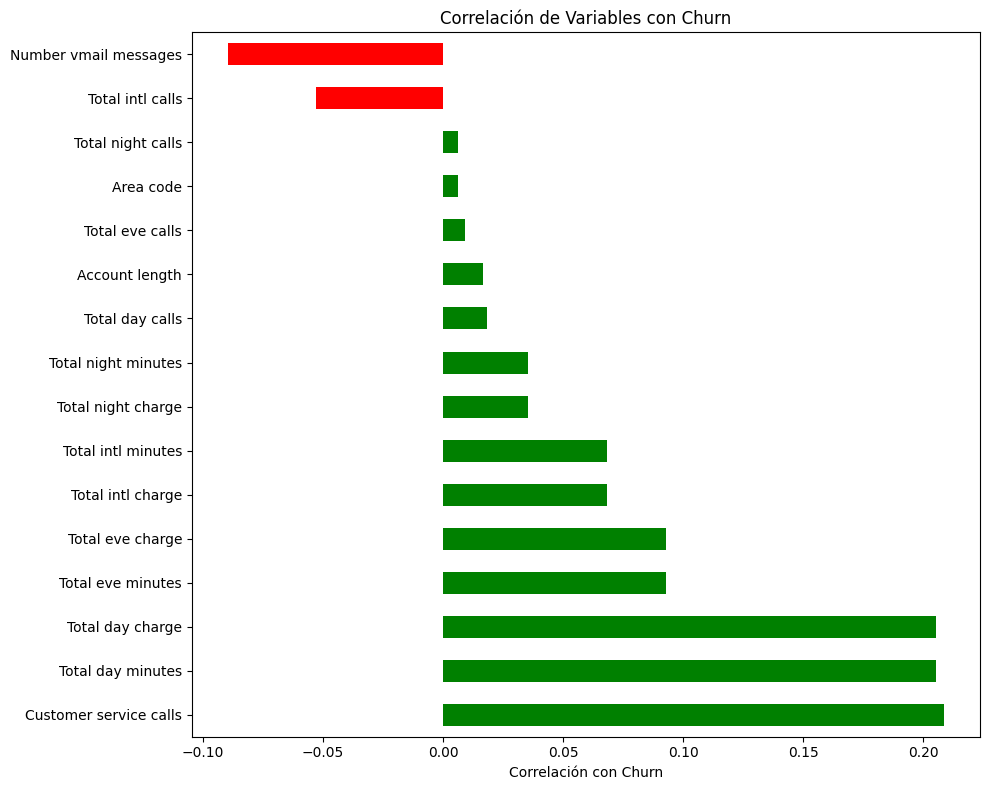

In [5]:
# Análisis de variables numéricas: Correlación con Churn
print("\n=== ANÁLISIS DE CORRELACIÓN CON CHURN ===\n")

# Convertir Churn a numérico para correlación y seleccionar solo numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64']).copy()
df_numeric['Churn'] = df['Churn'].astype(int)

# Calcular correlaciones
correlaciones = df_numeric.corr()['Churn'].sort_values(ascending=False)
print("Correlación de variables con Churn:")
print(correlaciones)

# Visualizar correlaciones
fig, ax = plt.subplots(figsize=(10, 8))
correlaciones.drop('Churn').plot(kind='barh', ax=ax, color=['green' if x > 0 else 'red' for x in correlaciones.drop('Churn')])
ax.set_xlabel('Correlación con Churn')
ax.set_title('Correlación de Variables con Churn')
plt.tight_layout()
plt.show()


=== MATRIZ DE CORRELACIÓN COMPLETA ===



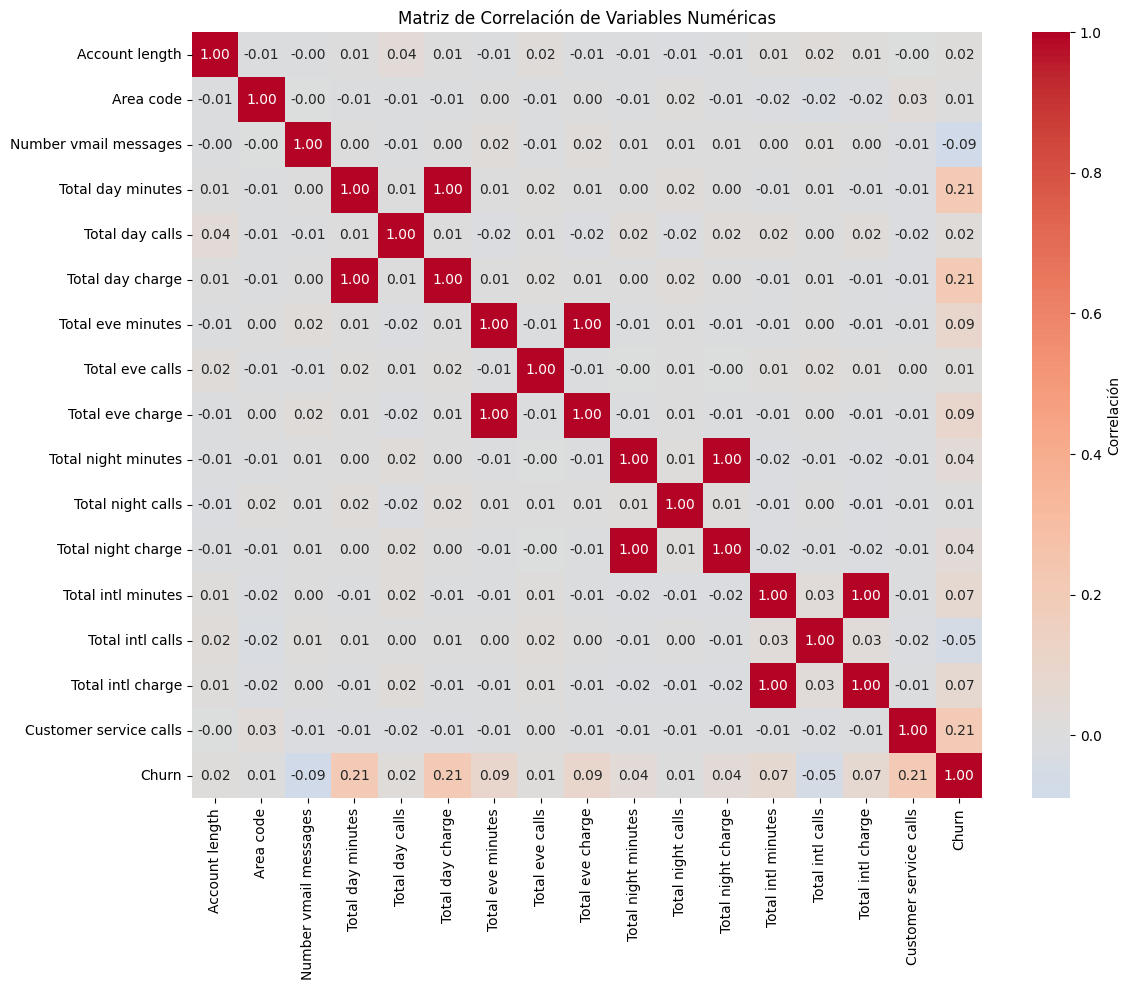

In [6]:
# Matriz de correlación completa
print("\n=== MATRIZ DE CORRELACIÓN COMPLETA ===\n")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()


=== ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===

              Variable          VIF
      Total day charge 1.246078e+08
     Total day minutes 1.246034e+08
      Total eve charge 3.741886e+07
     Total eve minutes 3.741752e+07
   Total night minutes 1.071952e+07
    Total night charge 1.071916e+07
     Total intl charge 9.979114e+05
    Total intl minutes 9.975354e+05
             Area code 6.102501e+01
     Total night calls 2.460108e+01
       Total eve calls 2.375305e+01
       Total day calls 2.361747e+01
        Account length 7.293103e+00
      Total intl calls 4.273501e+00
Customer service calls 2.402765e+00
 Number vmail messages 1.351056e+00

Interpretación VIF:
- VIF > 10: Alta multicolinealidad (problema)
- VIF 5-10: Multicolinealidad moderada (considerar remover)
- VIF < 5: Bajo riesgo de multicolinealidad


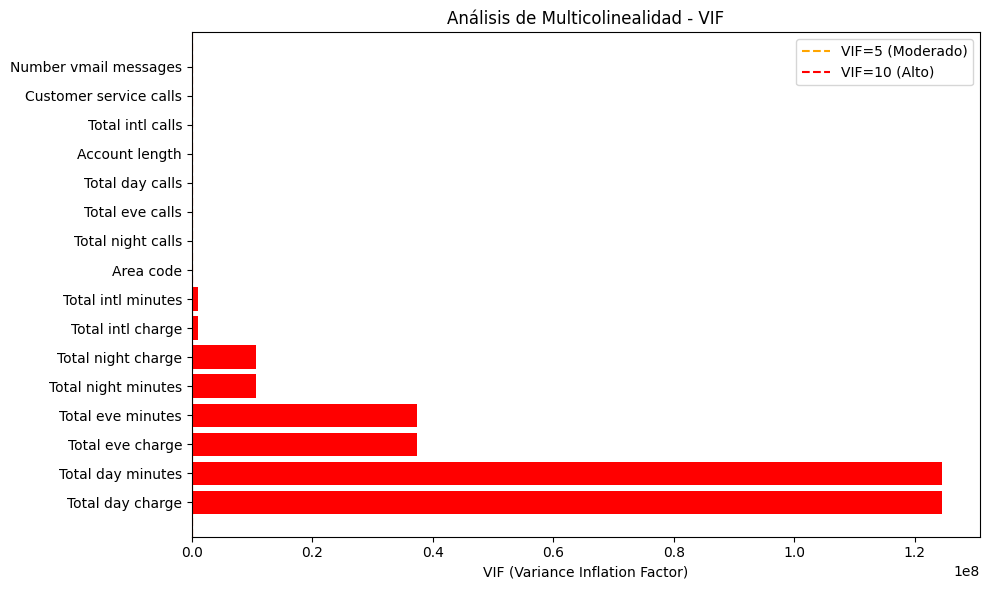

In [7]:
# Análisis de Multicolinealidad usando VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n=== ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===\n")

# Seleccionar solo variables numéricas (excluyendo Churn)
numeric_cols = df_numeric.select_dtypes(include=['int64', 'float64']).drop('Churn', axis=1).columns
X = df_numeric[numeric_cols]

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))
print("\nInterpretación VIF:")
print("- VIF > 10: Alta multicolinealidad (problema)")
print("- VIF 5-10: Multicolinealidad moderada (considerar remover)")
print("- VIF < 5: Bajo riesgo de multicolinealidad")

# Visualizar VIF
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_data['VIF']]
ax.barh(vif_data['Variable'], vif_data['VIF'], color=colors)
ax.axvline(x=5, color='orange', linestyle='--', label='VIF=5 (Moderado)')
ax.axvline(x=10, color='red', linestyle='--', label='VIF=10 (Alto)')
ax.set_xlabel('VIF (Variance Inflation Factor)')
ax.set_title('Análisis de Multicolinealidad - VIF')
ax.legend()
plt.tight_layout()
plt.show()


=== ANÁLISIS DE VARIABLES CATEGÓRICAS VS CHURN ===


State:
Churn  False  True   All
State                   
AK        49     3    52
AL        72     8    80
AR        44    11    55
AZ        60     4    64
CA        25     9    34
CO        57     9    66
CT        62    12    74
DC        49     5    54
DE        52     9    61
FL        55     8    63
GA        46     8    54
HI        50     3    53
IA        41     3    44
ID        64     9    73
IL        53     5    58
IN        62     9    71
KS        57    13    70
KY        51     8    59
LA        47     4    51
MA        54    11    65
MD        53    17    70
ME        49    13    62
MI        57    16    73
MN        69    15    84
MO        56     7    63
MS        51    14    65
MT        54    14    68
NC        57    11    68
ND        56     6    62
NE        56     5    61
NH        47     9    56
NJ        50    18    68
NM        56     6    62
NV        52    14    66
NY        68    15    83
OH        68  

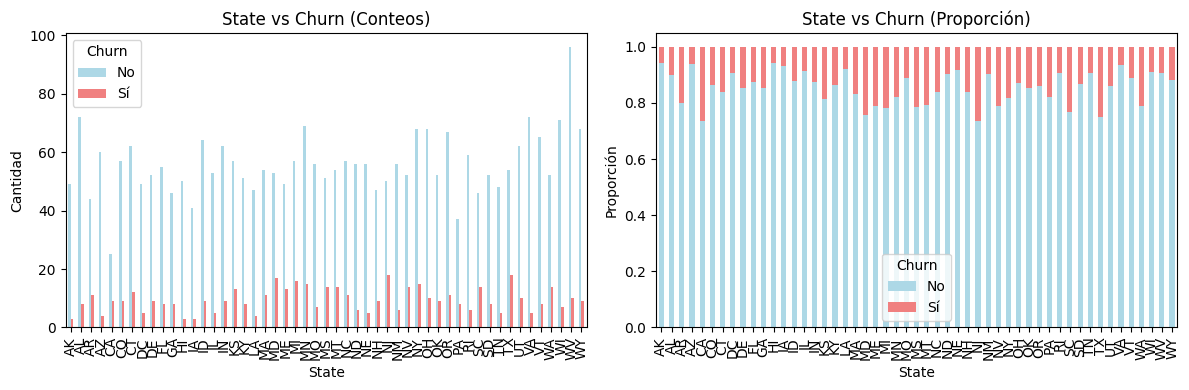


International plan:
Churn               False  True   All
International plan                   
No                   2664   346  3010
Yes                   186   137   323
All                  2850   483  3333


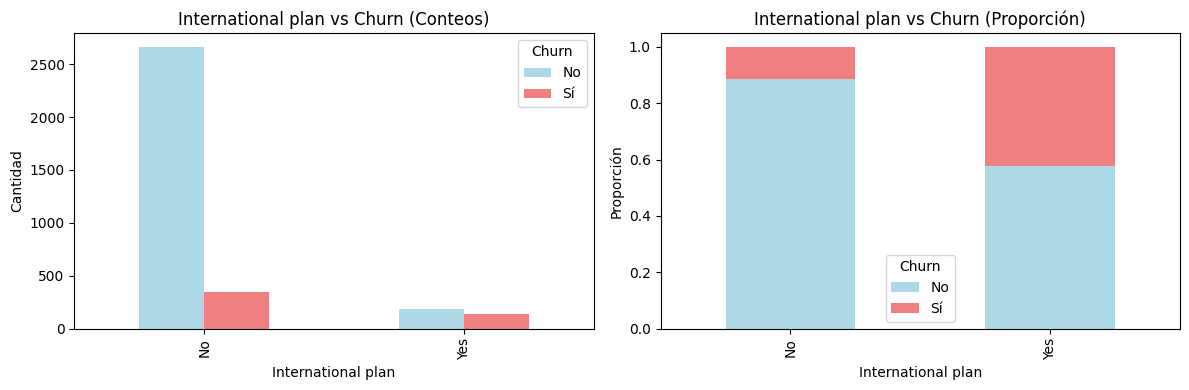


Voice mail plan:
Churn            False  True   All
Voice mail plan                   
No                2008   403  2411
Yes                842    80   922
All               2850   483  3333


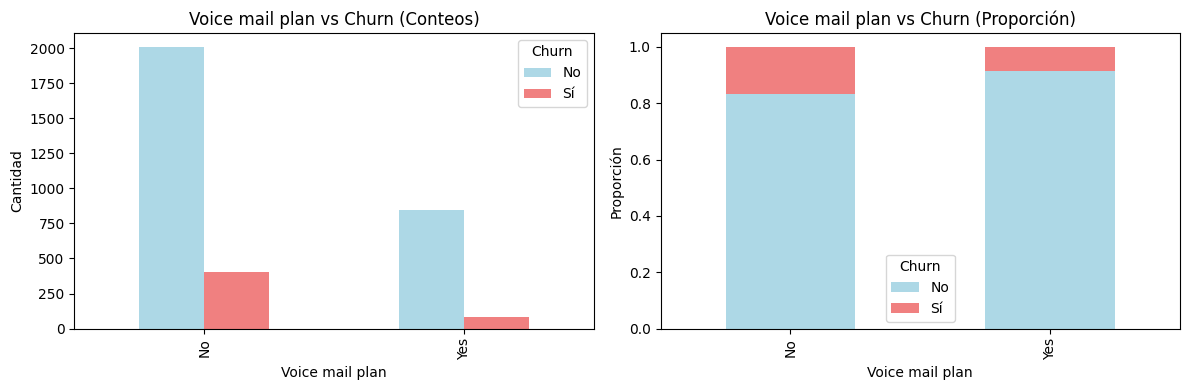

In [8]:
# Análisis de variables categóricas vs Churn
print("\n=== ANÁLISIS DE VARIABLES CATEGÓRICAS VS CHURN ===\n")

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{col}:")
    cross_tab = pd.crosstab(df[col], df['Churn'], margins=True)
    print(cross_tab)
    
    # Visualizar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico de barras con conteos
    cross_tab_no_margins = pd.crosstab(df[col], df['Churn'])
    cross_tab_no_margins.plot(kind='bar', ax=ax1, color=['lightblue', 'lightcoral'])
    ax1.set_title(f'{col} vs Churn (Conteos)')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Cantidad')
    ax1.legend(title='Churn', labels=['No', 'Sí'])
    
    # Gráfico de proporción
    cross_tab_prop = pd.crosstab(df[col], df['Churn'], normalize='index')
    cross_tab_prop.plot(kind='bar', ax=ax2, color=['lightblue', 'lightcoral'], stacked=True)
    ax2.set_title(f'{col} vs Churn (Proporción)')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Proporción')
    ax2.legend(title='Churn', labels=['No', 'Sí'])
    
    plt.tight_layout()
    plt.show()


=== ANÁLISIS DE DISTRIBUCIÓN DE VARIABLES NUMÉRICAS POR CHURN ===



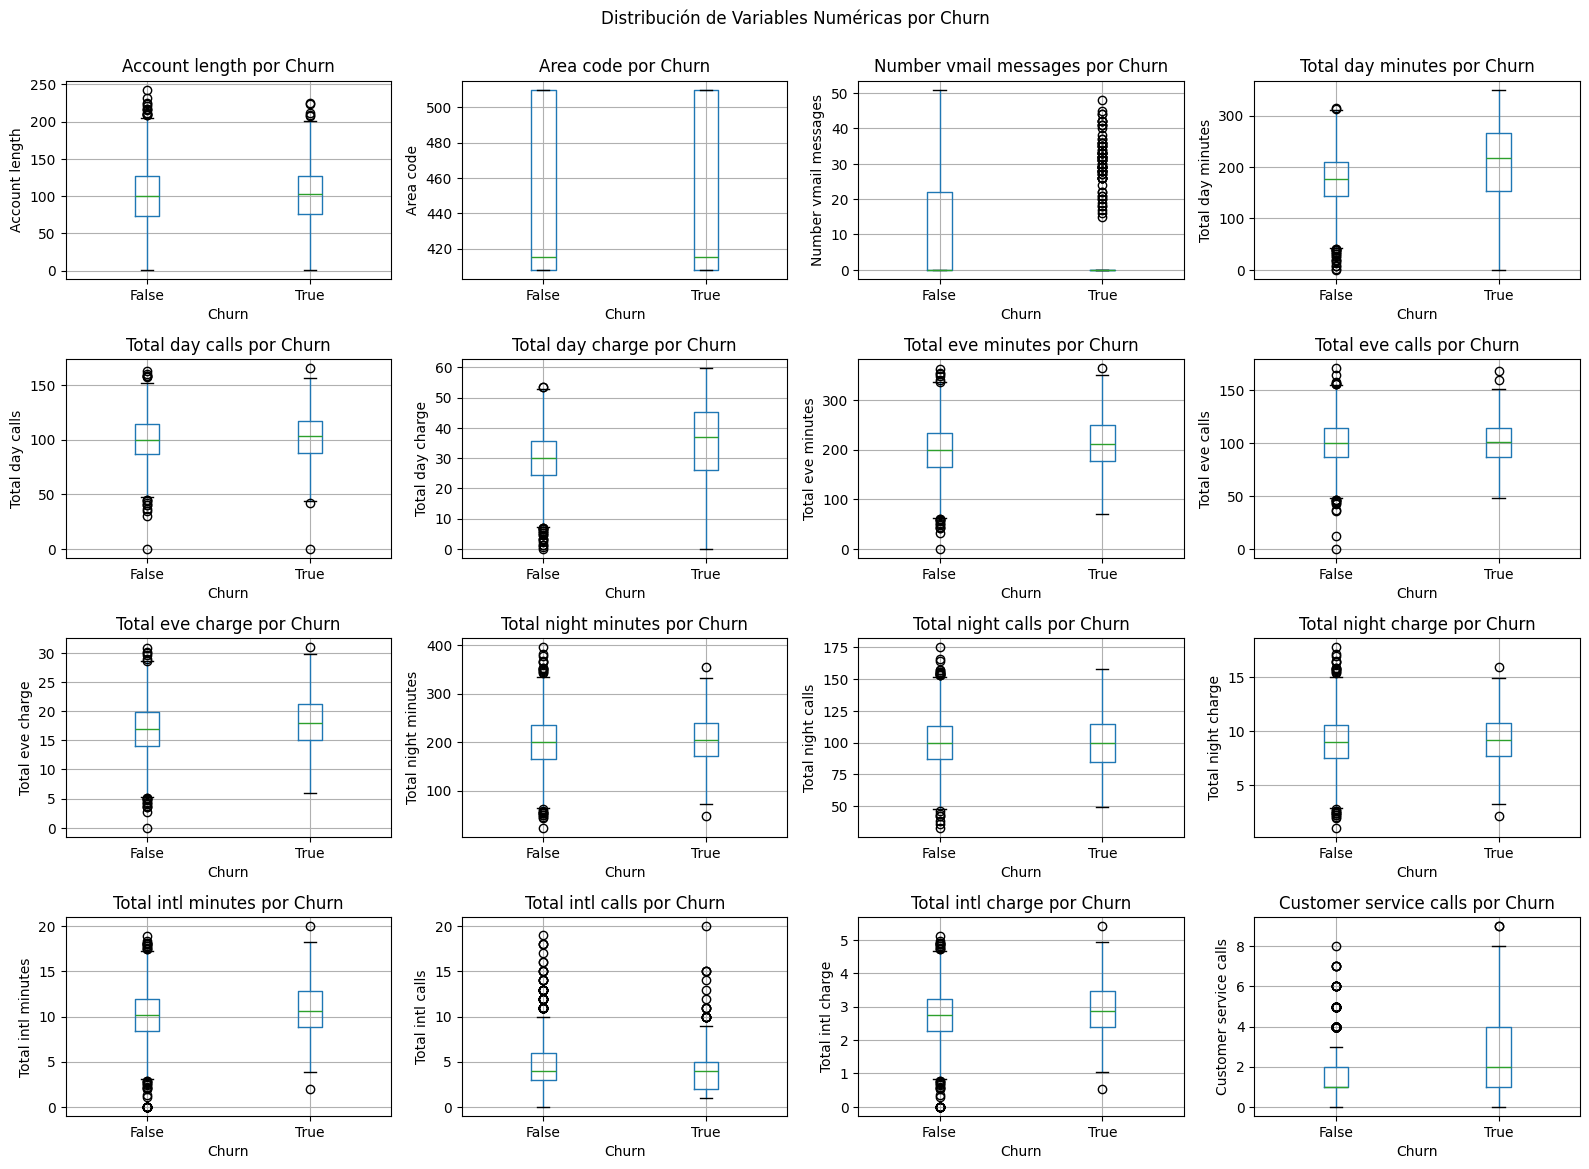

In [9]:
# Análisis de distribución de variables numéricas por Churn
print("\n=== ANÁLISIS DE DISTRIBUCIÓN DE VARIABLES NUMÉRICAS POR CHURN ===\n")

numeric_features = df_numeric.select_dtypes(include=['int64', 'float64']).drop('Churn', axis=1).columns

fig, axes = plt.subplots(5, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    ax = axes[idx]
    
    # Boxplot
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)

# Ocultar los ejes sobrantes
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas por Churn', y=1.00)
plt.tight_layout()
plt.show()

In [10]:
# Test estadísticos: Chi-cuadrado para categóricas
from scipy.stats import chi2_contingency, pointbiserialr

print("\n=== PRUEBAS ESTADÍSTICAS: CHI-CUADRADO (Variables Categóricas) ===\n")

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"{col}:")
    print(f"  Chi-cuadrado: {chi2:.4f}")
    print(f"  P-valor: {p_value:.6f}")
    print(f"  Significancia: {'SÍ (p < 0.05)' if p_value < 0.05 else 'NO'}\n")


=== PRUEBAS ESTADÍSTICAS: CHI-CUADRADO (Variables Categóricas) ===

State:
  Chi-cuadrado: 83.0438
  P-valor: 0.002296
  Significancia: SÍ (p < 0.05)

International plan:
  Chi-cuadrado: 222.5658
  P-valor: 0.000000
  Significancia: SÍ (p < 0.05)

Voice mail plan:
  Chi-cuadrado: 34.1317
  P-valor: 0.000000
  Significancia: SÍ (p < 0.05)



In [11]:
# Resumen ejecutivo del análisis exploratorio
print("\n" + "="*80)
print("RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO")
print("="*80 + "\n")

print("1. VARIABLE OBJETIVO (CHURN):")
print(f"   - Clientes que dejaron (Churn=True): {df['Churn'].sum()} ({df['Churn'].sum()/len(df)*100:.2f}%)")
print(f"   - Clientes que se quedaron (Churn=False): {(~df['Churn']).sum()} ({(~df['Churn']).sum()/len(df)*100:.2f}%)")

print("\n2. VARIABLES MÁS CORRELACIONADAS CON CHURN:")
top_corr = correlaciones.drop('Churn').abs().nlargest(5)
for var, corr in top_corr.items():
    actual_corr = correlaciones[var]
    print(f"   - {var}: {actual_corr:.4f}")

print("\n3. MULTICOLINEALIDAD CRÍTICA (VIF > 10):")
problematic = vif_data[vif_data['VIF'] > 10]
if len(problematic) > 0:
    for _, row in problematic.iterrows():
        print(f"   - {row['Variable']}: VIF={row['VIF']:.2f}")
else:
    print("   - No se encontraron variables con VIF > 10")

print("\n4. MULTICOLINEALIDAD MODERADA (5 < VIF ≤ 10):")
moderate = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]
if len(moderate) > 0:
    for _, row in moderate.iterrows():
        print(f"   - {row['Variable']}: VIF={row['VIF']:.2f}")
else:
    print("   - No se encontraron variables con VIF moderado")

print("\n5. VARIABLES CATEGÓRICAS SIGNIFICATIVAS (p < 0.05):")
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    if p_value < 0.05:
        print(f"   - {col}: p-valor={p_value:.6f} ✓")


RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO

1. VARIABLE OBJETIVO (CHURN):
   - Clientes que dejaron (Churn=True): 483 (14.49%)
   - Clientes que se quedaron (Churn=False): 2850 (85.51%)

2. VARIABLES MÁS CORRELACIONADAS CON CHURN:
   - Customer service calls: 0.2087
   - Total day minutes: 0.2052
   - Total day charge: 0.2052
   - Total eve minutes: 0.0928
   - Total eve charge: 0.0928

3. MULTICOLINEALIDAD CRÍTICA (VIF > 10):
   - Total day charge: VIF=124607849.22
   - Total day minutes: VIF=124603367.35
   - Total eve charge: VIF=37418859.61
   - Total eve minutes: VIF=37417517.03
   - Total night minutes: VIF=10719516.30
   - Total night charge: VIF=10719161.26
   - Total intl charge: VIF=997911.43
   - Total intl minutes: VIF=997535.40
   - Area code: VIF=61.03
   - Total night calls: VIF=24.60
   - Total eve calls: VIF=23.75
   - Total day calls: VIF=23.62

4. MULTICOLINEALIDAD MODERADA (5 < VIF ≤ 10):
   - Account length: VIF=7.29

5. VARIABLES CATEGÓRICAS SIGNIFICATIVAS (p < 0.

In [13]:
print("\n" + "="*80)
print("RECOMENDACIONES Y CONCLUSIONES")
print("="*80 + "\n")

print("📊 HALLAZGOS PRINCIPALES:\n")

print("1. PROBLEMA DE MULTICOLINEALIDAD:")
print("   ⚠️  Hay GRAVE multicolinealidad entre variables de minutos y cargos (charges).")
print("   Las variables de cargos (charges) son derivadas de minutos * tarifa, causando")
print("   correlación casi perfecta (1.0). Esto hace que los modelos interpreten mal")
print("   la importancia de las características.\n")

print("   Recomendación: REMOVER una de cada par:")
print("   - Remover Total day charge, Total eve charge, Total night charge, Total intl charge")
print("   - Mantener solo: Total day minutes, Total eve minutes, Total night minutes, Total intl minutes\n")

print("2. PREDICTORES IMPORTANTES PARA CHURN:\n")
print("   ✓ Customer service calls (r=0.209)")
print("     - ALTA correlación: Clientes que llaman más al soporte tienden a abandonar")
print("     - Posible indicador de insatisfacción\n")

print("   ✓ Total day minutes (r=0.205)")
print("     - Clientes con MAYOR uso de minutos diurnos TIENDEN a abandonar")
print("     - Podría indicar clientes insatisfechos o buscando alternativas\n")

print("   ✓ Total eve minutes (r=0.093)")
print("     - Correlación débil positiva con churn\n")

print("   ✓ Number vmail messages (r=-0.090)")
print("     - Correlación NEGATIVA: Clientes con correo de voz tienden a QUEDARSE\n")

print("3. FACTORES CATEGÓRICOS SIGNIFICATIVOS:\n")
print("   ✓ International plan (p=0.000000)")
print("     - 42.4% de clientes CON plan internacional abandonan")
print("     - 11.5% de clientes SIN plan internacional abandonan")
print("     - ALTO impacto en churn\n")

print("   ✓ Voice mail plan (p=0.000000)")
print("     - 8.7% de clientes CON correo de voz abandonan")
print("     - 16.7% de clientes SIN correo de voz abandonan\n")

print("   ✓ State (p=0.002296)")
print("     - Variabilidad geográfica en churn (menor impacto que planes)\n")

print("\n" + "="*80)
print("🎯 ESTRATEGIA DE MODELADO RECOMENDADA:")
print("="*80 + "\n")

print("1. SELECCIÓN DE VARIABLES:")
print("   - Remover variables de 'cargos' (charges) para evitar multicolinealidad")
print("   - Mantener minutos y llamadas (features más interpretables)")
print("   - Incluir International plan y Voice mail plan (muy significativos)")
print("   - State podría agruparse o usarse como dummy")
print("   - Customer service calls es muy predictivo\n")

print("2. MANEJO DE DESBALANCE:")
print("   - Dataset está desbalanceado (14.5% churn, 85.5% sin churn)")
print("   - Considerar: SMOTE, class_weight, balanced_random_forest, estratificación\n")

print("3. MODELOS RECOMENDADOS:")
print("   - Logistic Regression (interpretabilidad)")
print("   - Random Forest (maneja no-linealidades)")
print("   - Gradient Boosting (XGBoost, LightGBM)")
print("   - Usar validación cruzada estratificada\n")

print("="*80)


RECOMENDACIONES Y CONCLUSIONES

📊 HALLAZGOS PRINCIPALES:

1. PROBLEMA DE MULTICOLINEALIDAD:
   ⚠️  Hay GRAVE multicolinealidad entre variables de minutos y cargos (charges).
   Las variables de cargos (charges) son derivadas de minutos * tarifa, causando
   correlación casi perfecta (1.0). Esto hace que los modelos interpreten mal
   la importancia de las características.

   Recomendación: REMOVER una de cada par:
   - Remover Total day charge, Total eve charge, Total night charge, Total intl charge
   - Mantener solo: Total day minutes, Total eve minutes, Total night minutes, Total intl minutes

2. PREDICTORES IMPORTANTES PARA CHURN:

   ✓ Customer service calls (r=0.209)
     - ALTA correlación: Clientes que llaman más al soporte tienden a abandonar
     - Posible indicador de insatisfacción

   ✓ Total day minutes (r=0.205)
     - Clientes con MAYOR uso de minutos diurnos TIENDEN a abandonar
     - Podría indicar clientes insatisfechos o buscando alternativas

   ✓ Total eve minut

In [15]:
# Comparativa estadística: Churn vs No Churn
print("\n" + "="*80)
print("COMPARATIVA ESTADÍSTICA: CHURN vs NO CHURN")
print("="*80 + "\n")

# Seleccionar variables numéricas
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

comparison = pd.DataFrame({
    'Variable': numeric_features,
    'No Churn (Media)': [df[df['Churn']==False][col].mean() for col in numeric_features],
    'Churn (Media)': [df[df['Churn']==True][col].mean() for col in numeric_features],
})

comparison['Diferencia %'] = ((comparison['Churn (Media)'] - comparison['No Churn (Media)']) / 
                               comparison['No Churn (Media)'] * 100)
comparison = comparison.sort_values('Diferencia %', ascending=False, key=abs)

print(comparison.to_string(index=False))

print("\n\nINTERPRETACIÓN:")
print("Las variables con MAYOR diferencia entre grupos son las más discriminativas:\n")

for _, row in comparison.head(8).iterrows():
    var = row['Variable']
    diff = row['Diferencia %']
    no_churn = row['No Churn (Media)']
    churn = row['Churn (Media)']
    
    direction = "MAYOR ↑" if diff > 0 else "MENOR ↓"
    print(f"• {var}:")
    print(f"  No Churn: {no_churn:.2f} | Churn: {churn:.2f} ({direction} {abs(diff):.1f}%)\n")


COMPARATIVA ESTADÍSTICA: CHURN vs NO CHURN

              Variable  No Churn (Media)  Churn (Media)  Diferencia %
Customer service calls          1.449825       2.229814     53.798861
 Number vmail messages          8.604561       5.115942    -40.543837
     Total day minutes        175.175754     206.914079     18.117989
      Total day charge         29.780421      35.175921     18.117609
      Total intl calls          4.532982       4.163561     -8.149632
     Total eve minutes        199.043298     212.410145      6.715547
      Total eve charge         16.918909      18.054969      6.714737
     Total intl charge          2.743404       2.889545      5.326996
    Total intl minutes         10.158877      10.700000      5.326601
    Total night charge          9.006074       9.235528      2.547772
   Total night minutes        200.133193     205.231677      2.547545
        Account length        100.793684     102.664596      1.856180
       Total day calls        100.283158     

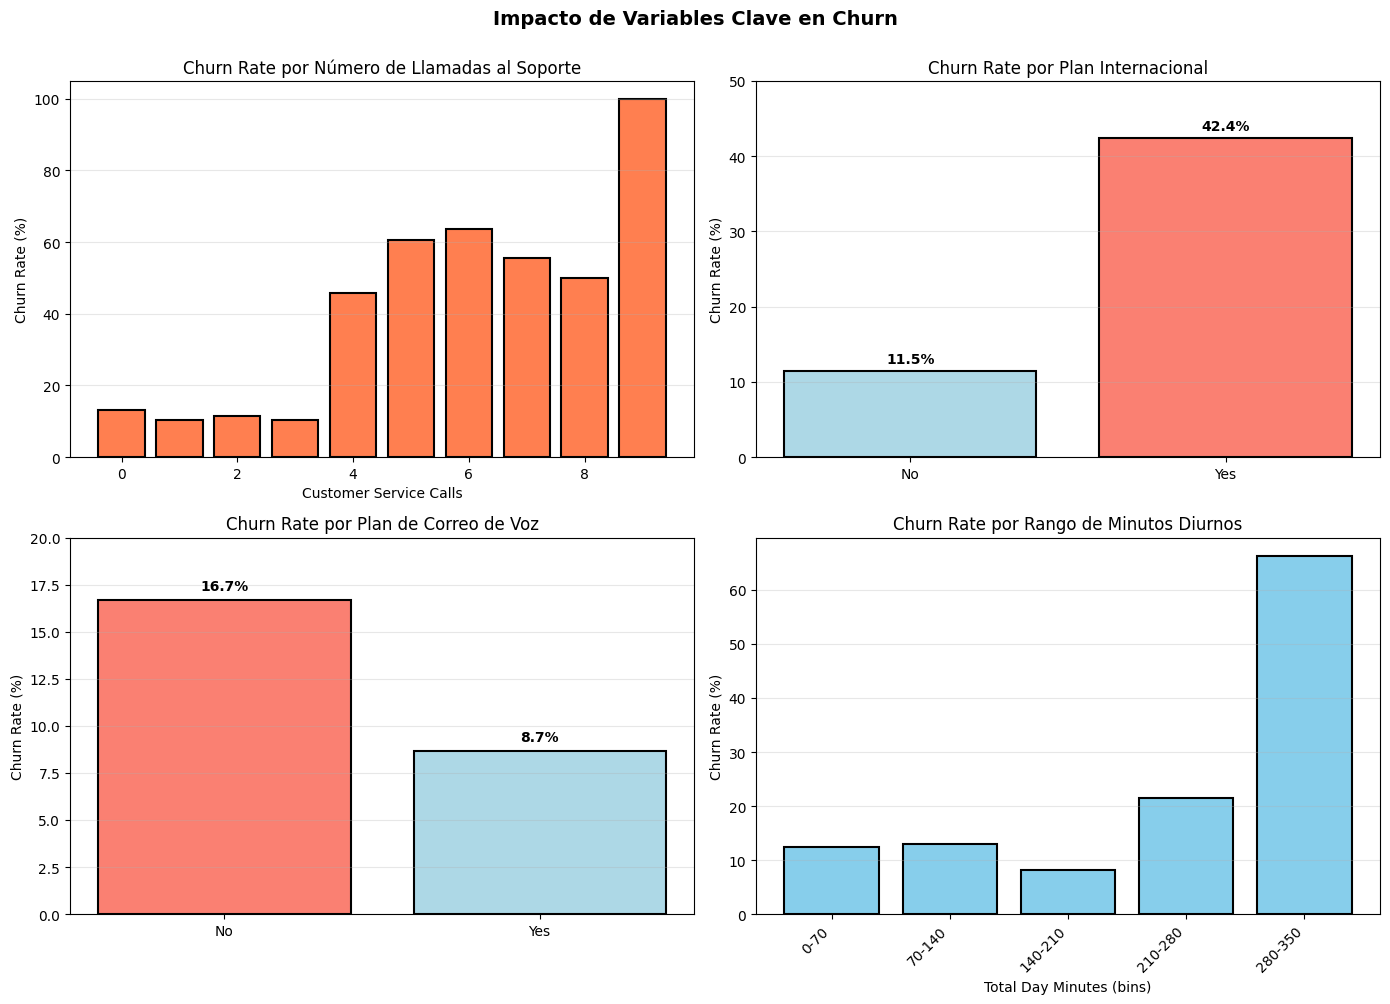


✓ Análisis Exploratorio Completo


In [16]:
# Visualización de impacto de variables clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Llamadas al servicio al cliente
ax = axes[0, 0]
churn_by_calls = df.groupby('Customer service calls')['Churn'].agg(['sum', 'count'])
churn_by_calls['churn_rate'] = churn_by_calls['sum'] / churn_by_calls['count'] * 100
ax.bar(churn_by_calls.index, churn_by_calls['churn_rate'], color='coral', edgecolor='black', linewidth=1.5)
ax.set_xlabel('Customer Service Calls')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate por Número de Llamadas al Soporte')
ax.grid(axis='y', alpha=0.3)

# 2. Plan Internacional
ax = axes[0, 1]
intl_plan_churn = df.groupby('International plan')['Churn'].apply(lambda x: (x.sum()/len(x)*100))
colors_intl = ['lightblue', 'salmon']
bars = ax.bar(intl_plan_churn.index, intl_plan_churn.values, color=colors_intl, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate por Plan Internacional')
ax.set_ylim(0, 50)
for i, (idx, val) in enumerate(intl_plan_churn.items()):
    ax.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 3. Plan de Correo de Voz
ax = axes[1, 0]
vmail_churn = df.groupby('Voice mail plan')['Churn'].apply(lambda x: (x.sum()/len(x)*100))
colors_vmail = ['salmon', 'lightblue']
bars = ax.bar(vmail_churn.index, vmail_churn.values, color=colors_vmail, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate por Plan de Correo de Voz')
ax.set_ylim(0, 20)
for i, (idx, val) in enumerate(vmail_churn.items()):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. Minutos de uso diurno
ax = axes[1, 1]
# Crear bins de minutos diurnos
df['day_minutes_bin'] = pd.cut(df['Total day minutes'], bins=5)
day_mins_churn = df.groupby('day_minutes_bin', observed=True)['Churn'].apply(lambda x: (x.sum()/len(x)*100))
labels = [f'{int(interval.left)}-{int(interval.right)}' for interval in day_mins_churn.index]
ax.bar(range(len(labels)), day_mins_churn.values, color='skyblue', edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Total Day Minutes (bins)')
ax.set_title('Churn Rate por Rango de Minutos Diurnos')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Impacto de Variables Clave en Churn', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Análisis Exploratorio Completo")